<a href="https://colab.research.google.com/github/jorigo/Reto1_TelecomX/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
import pandas as pd

# Ruta completa al archivo JSON en Google Drive
drive_file_path = '/content/drive/MyDrive/Colab Notebooks/Archivos_Pandas_DataBase/TelecomX_Data.json'

# Importar los datos desde el archivo JSON del Drive
df = pd.read_json(drive_file_path)

# Mostrar las primeras filas del DataFrame para verificar la importación
print(df.head())

   customerID Churn                                           customer  \
0  0002-ORFBO    No  {'gender': 'Female', 'SeniorCitizen': 0, 'Part...   
1  0003-MKNFE    No  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
2  0004-TLHLJ   Yes  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
3  0011-IGKFF   Yes  {'gender': 'Male', 'SeniorCitizen': 1, 'Partne...   
4  0013-EXCHZ   Yes  {'gender': 'Female', 'SeniorCitizen': 1, 'Part...   

                                             phone  \
0   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
1  {'PhoneService': 'Yes', 'MultipleLines': 'Yes'}   
2   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
3   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
4   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   

                                            internet  \
0  {'InternetService': 'DSL', 'OnlineSecurity': '...   
1  {'InternetService': 'DSL', 'OnlineSecurity': '...   
2  {'InternetService': 'Fiber optic', 'OnlineSecu...   
3  {'I

#🔧 Transformación

In [15]:
# Aplanar la columna 'phone'
df_phone = pd.json_normalize(df['phone'])
df = pd.concat([df.drop(columns=['phone']), df_phone], axis=1)

# Aplanar la columna 'internet'
df_internet = pd.json_normalize(df['internet'])
df = pd.concat([df.drop(columns=['internet']), df_internet], axis=1)

# Aplanar la columna 'account'
df_account = pd.json_normalize(df['account'])
df = pd.concat([df.drop(columns=['account']), df_account], axis=1)

print("DataFrame después de aplanar todas las columnas anidadas:")
print(df.head())
print(df.info())
print(df.dtypes)

DataFrame después de aplanar todas las columnas anidadas:
   customerID Churn                                           customer  \
0  0002-ORFBO    No  {'gender': 'Female', 'SeniorCitizen': 0, 'Part...   
1  0003-MKNFE    No  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
2  0004-TLHLJ   Yes  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
3  0011-IGKFF   Yes  {'gender': 'Male', 'SeniorCitizen': 1, 'Partne...   
4  0013-EXCHZ   Yes  {'gender': 'Female', 'SeniorCitizen': 1, 'Part...   

  PhoneService MultipleLines InternetService OnlineSecurity OnlineBackup  \
0          Yes            No             DSL             No          Yes   
1          Yes           Yes             DSL             No           No   
2          Yes            No     Fiber optic             No           No   
3          Yes            No     Fiber optic             No          Yes   
4          Yes            No     Fiber optic             No           No   

  DeviceProtection TechSupport Streaming

In [17]:
# 1. Corrección de formato para 'Charges.Total'
# Reemplazar valores vacíos con NaN y convertir a numérico
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')

print("\nDespués de corregir 'Charges.Total':")
print(df[['Charges.Total']].head())
print(df['Charges.Total'].dtype)

# Aplanar la columna 'customer' antes de cualquier operación que requiera valores hashables
df_customer = pd.json_normalize(df['customer'])
df = pd.concat([df.drop(columns=['customer']), df_customer], axis=1)

# 2. Verificación de valores ausentes
print("\nValores ausentes por columna:")
print(df.isnull().sum())

# 3. Verificación de duplicados
print("\nNúmero de filas duplicadas:")
print(df.duplicated().sum())

# 4. Verificación de inconsistencias en categorías (columnas tipo 'object')
print("\nValores únicos en columnas categóricas (primeros 10 por columna):")
for column in df.select_dtypes(include='object').columns:
    if column not in ['ID_Cliente']:
        unique_values = df[column].unique()
        print(f"- {column}: {unique_values[:10]}")
        if len(unique_values) > 10:
            print(f"  (y {len(unique_values) - 10} más)")


Después de corregir 'Charges.Total':
   Charges.Total
0         593.30
1         542.40
2         280.85
3        1237.85
4         267.40
float64

Valores ausentes por columna:
customerID           0
Churn                0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
Charges.Monthly      0
Charges.Total       11
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
dtype: int64

Número de filas duplicadas:
0

Valores únicos en columnas categóricas (primeros 10 por columna):
- customerID: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' '0011-IGKFF' '0013-EXCHZ'
 '0013-MHZWF' '0013-SMEOE' '0014-BMAQU' '0015-UOCOJ' '0016-QLJIS']
  (y 7257 más)
- Churn: ['No' 'Yes' '']
- PhoneService: ['Yes' 'No']
- MultipleL

In [18]:
# 1. borrar valores NaN en 'Charges.Total' con la mediana
median_charges_total = df['Charges.Total'].median()
df['Charges.Total'].fillna(median_charges_total, inplace=True)
print(f"Valores NaN en 'Charges.Total' después de la imputación: {df['Charges.Total'].isnull().sum()}")

# 2. Corregir inconsistencia en la columna 'Churn': reemplazar '' con 'No'
df['Churn'] = df['Churn'].replace('', 'No')
print(f"Valores únicos en 'Churn' después de la corrección: {df['Churn'].unique()}")

# 3. Demostrar string manipulation (.lower()) en algunas columnas categóricas
for col in ['gender', 'Contract']:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].str.lower()
        print(f"Valores únicos en '{col}' después de .lower(): {df[col].unique()}")

print("\nVerificación final de valores ausentes:")
print(df.isnull().sum())

print("\nDataFrame después de las correcciones (primeras 5 filas):")
print(df.head())

Valores NaN en 'Charges.Total' después de la imputación: 0
Valores únicos en 'Churn' después de la corrección: ['No' 'Yes']
Valores únicos en 'gender' después de .lower(): ['female' 'male']
Valores únicos en 'Contract' después de .lower(): ['one year' 'month-to-month' 'two year']

Verificación final de valores ausentes:
customerID          0
Churn               0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
dtype: int64

DataFrame después de las correcciones (primeras 5 filas):
   customerID Churn PhoneService MultipleLines InternetService OnlineSecurity  \
0  0002-ORFBO    No          Yes            No             DSL 

/tmp/ipykernel_330/1192808440.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Charges.Total'].fillna(median_charges_total, inplace=True)


In [19]:
# Crear la columna 'Cuentas_Diarias' a partir de 'Charges.Monthly'
df['Cuentas_Diarias'] = df['Charges.Monthly'] / 30

print("DataFrame con la nueva columna 'Cuentas_Diarias' (primeras 5 filas):")
print(df[['Charges.Monthly', 'Cuentas_Diarias']].head())
print(f"Tipo de dato de 'Cuentas_Diarias': {df['Cuentas_Diarias'].dtype}")

DataFrame con la nueva columna 'Cuentas_Diarias' (primeras 5 filas):
   Charges.Monthly  Cuentas_Diarias
0             65.6         2.186667
1             59.9         1.996667
2             73.9         2.463333
3             98.0         3.266667
4             83.9         2.796667
Tipo de dato de 'Cuentas_Diarias': float64


In [20]:
# Mapeo de valores binarios estándar (Sí/No a 1/0)
binary_map = {'Yes': 1, 'No': 0}

# Columnas con solo 'Yes'/'No' que se binarizarán directamente
cols_to_binarize_simple = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in cols_to_binarize_simple:
    df[col] = df[col].map(binary_map)

# Columna 'gender': Mapear 'female' a 0 y 'male' a 1
df['gender'] = df['gender'].map({'female': 0, 'male': 1})

# Columnas con 'No service' que se binarizarán (Yes=1, No/No service=0)
cols_with_no_service_to_binarize = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for col in cols_with_no_service_to_binarize:
    # Reemplazar los valores de 'No service' por 'No' antes de mapear
    df[col] = df[col].replace({'No phone service': 'No', 'No internet service': 'No'}).map(binary_map)

# Renombrar columnas a español para mayor claridad
new_column_names = {
    'customerID': 'ID_Cliente',
    'Churn': 'Abandono',
    'gender': 'Genero',
    'SeniorCitizen': 'Ciudadano_Senior',
    'Partner': 'Pareja',
    'Dependents': 'Dependientes',
    'tenure': 'Antiguedad_Meses',
    'PhoneService': 'Servicio_Telefonico',
    'MultipleLines': 'Multiples_Lineas',
    'InternetService': 'Servicio_Internet', # Mantener como categórica por ahora
    'OnlineSecurity': 'Seguridad_Online',
    'OnlineBackup': 'Copia_Seguridad_Online',
    'DeviceProtection': 'Proteccion_Dispositivo',
    'TechSupport': 'Soporte_Tecnico',
    'StreamingTV': 'Television_Streaming',
    'StreamingMovies': 'Peliculas_Streaming',
    'Contract': 'Contrato', # Mantener como categórica por ahora
    'PaperlessBilling': 'Facturacion_Sin_Papel',
    'PaymentMethod': 'Metodo_Pago', # Mantener como categórica por ahora
    'Charges.Monthly': 'Cargos_Mensuales',
    'Charges.Total': 'Cargos_Totales',
    'Cuentas_Diarias': 'Cargos_Diarios'
}

df = df.rename(columns=new_column_names)

print("\nDataFrame después de binarizar y renombrar (primeras 5 filas):")
print(df.head())
print("\nTipos de datos después de la transformación:")
print(df.dtypes)
print("\nValores únicos en algunas columnas binarizadas para verificación:")
print(f"Abandono: {df['Abandono'].unique()}")
print(f"Genero: {df['Genero'].unique()}")
print(f"Servicio_Telefonico: {df['Servicio_Telefonico'].unique()}")
print(f"Seguridad_Online: {df['Seguridad_Online'].unique()}")


DataFrame después de binarizar y renombrar (primeras 5 filas):
   ID_Cliente  Abandono  Servicio_Telefonico  Multiples_Lineas  \
0  0002-ORFBO         0                    1                 0   
1  0003-MKNFE         0                    1                 1   
2  0004-TLHLJ         1                    1                 0   
3  0011-IGKFF         1                    1                 0   
4  0013-EXCHZ         1                    1                 0   

  Servicio_Internet  Seguridad_Online  Copia_Seguridad_Online  \
0               DSL                 0                       1   
1               DSL                 0                       0   
2       Fiber optic                 0                       0   
3       Fiber optic                 0                       1   
4       Fiber optic                 0                       0   

   Proteccion_Dispositivo  Soporte_Tecnico  Television_Streaming  ...  \
0                       0                1                     1  ...   
1 

#📊 Carga y análisis

In [21]:
print("\nAnálisis Descriptivo de los Datos:")
print(df.describe())


Análisis Descriptivo de los Datos:
          Abandono  Servicio_Telefonico  Multiples_Lineas  Seguridad_Online  \
count  7267.000000          7267.000000       7267.000000       7267.000000   
mean      0.257190             0.902711          0.421770          0.285950   
std       0.437115             0.296371          0.493876          0.451897   
min       0.000000             0.000000          0.000000          0.000000   
25%       0.000000             1.000000          0.000000          0.000000   
50%       0.000000             1.000000          0.000000          0.000000   
75%       1.000000             1.000000          1.000000          1.000000   
max       1.000000             1.000000          1.000000          1.000000   

       Copia_Seguridad_Online  Proteccion_Dispositivo  Soporte_Tecnico  \
count             7267.000000             7267.000000      7267.000000   
mean                 0.344571                0.342782         0.289528   
std                  0.475261 

/tmp/ipykernel_330/1180074883.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Abandono', data=df, palette='viridis')


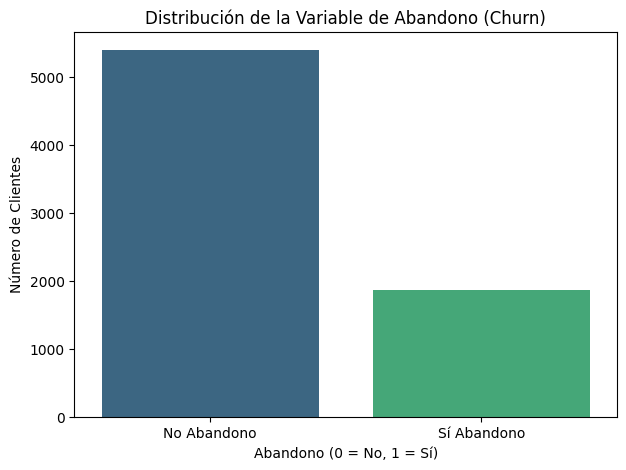

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.countplot(x='Abandono', data=df, palette='viridis')
plt.title('Distribución de la Variable de Abandono (Churn)')
plt.xlabel('Abandono (0 = No, 1 = Sí)')
plt.ylabel('Número de Clientes')
plt.xticks(ticks=[0, 1], labels=['No Abandono', 'Sí Abandono'])
plt.show()

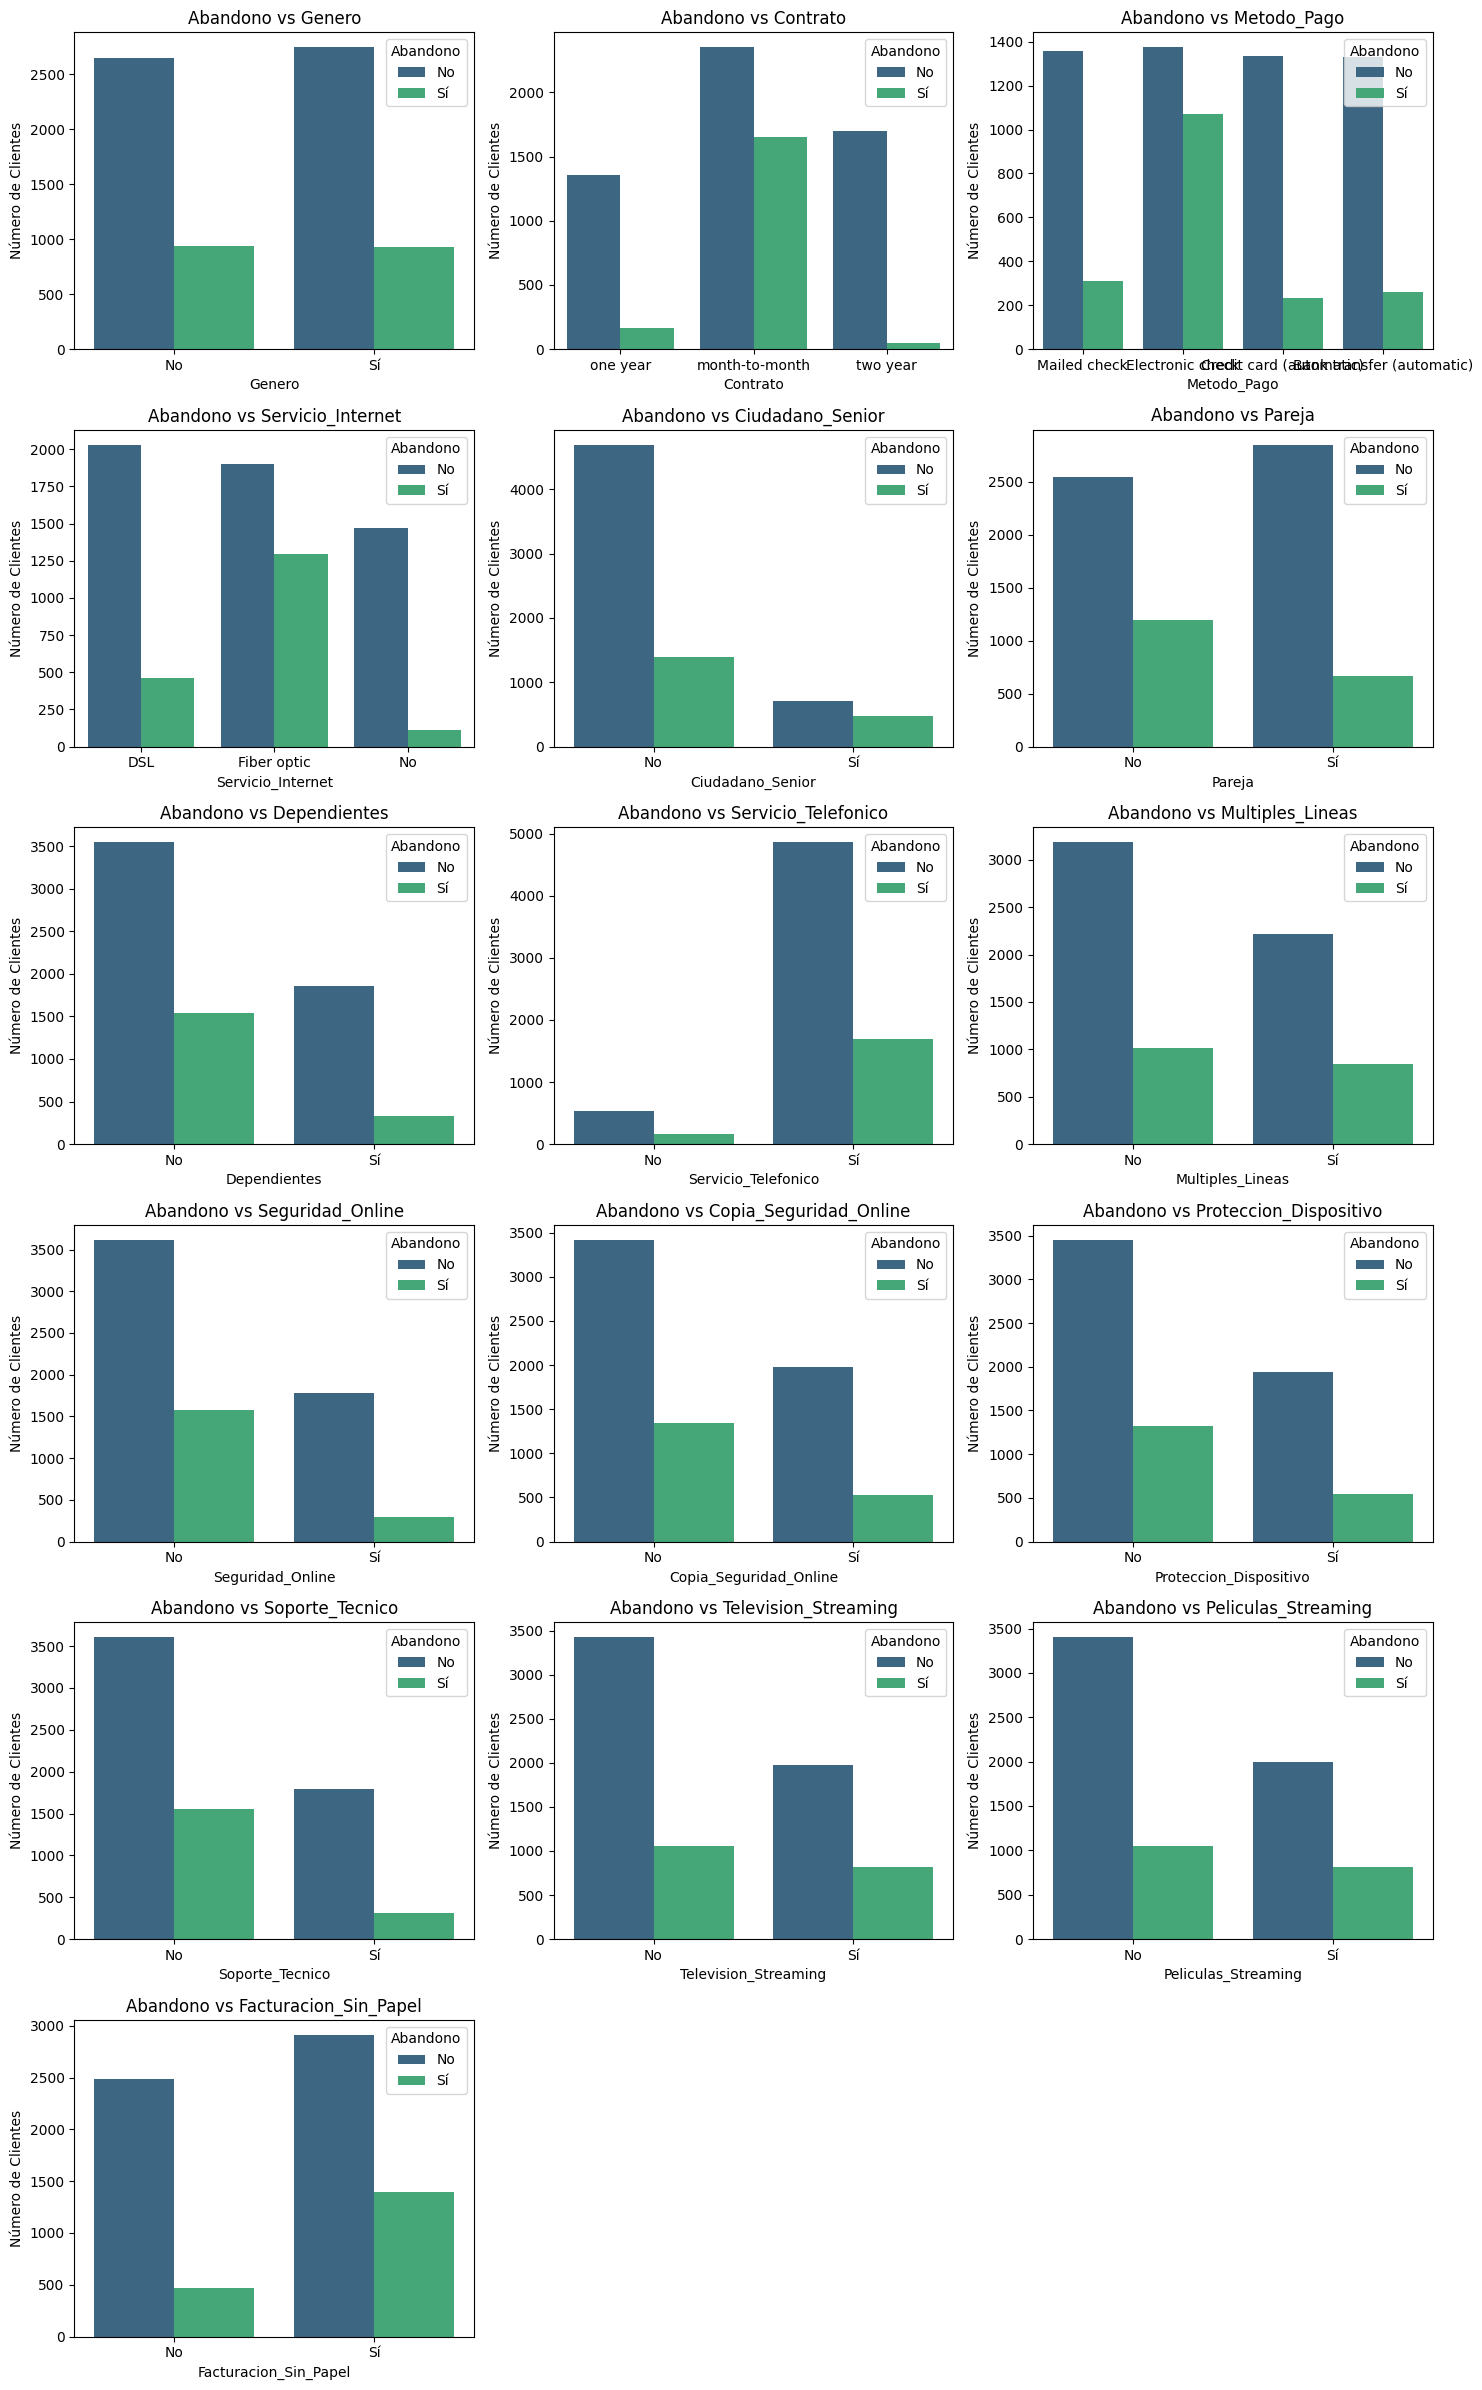

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = [
    'Genero', 'Contrato', 'Metodo_Pago', 'Servicio_Internet',
    'Ciudadano_Senior', 'Pareja', 'Dependientes',
    'Servicio_Telefonico', 'Multiples_Lineas', 'Seguridad_Online',
    'Copia_Seguridad_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico',
    'Television_Streaming', 'Peliculas_Streaming', 'Facturacion_Sin_Papel'
]

# Ajustar el tamaño de la figura dinámicamente según el número de columnas
num_plots = len(categorical_cols)
num_cols = 3  # Número de columnas para los subplots
num_rows = (num_plots + num_cols - 1) // num_cols # Calcular el número de filas necesarias

plt.figure(figsize=(num_cols * 5, num_rows * 4))

for i, col in enumerate(categorical_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.countplot(x=col, hue='Abandono', data=df, palette='viridis')
    plt.title(f'Abandono vs {col}')
    plt.xlabel(col)
    plt.ylabel('Número de Clientes')
    # Ajustar etiquetas para columnas binarizadas si es necesario
    if col in ['Servicio_Telefonico', 'Multiples_Lineas', 'Seguridad_Online',
               'Copia_Seguridad_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico',
               'Television_Streaming', 'Peliculas_Streaming', 'Facturacion_Sin_Papel',
               'Ciudadano_Senior', 'Pareja', 'Dependientes', 'Genero']:
        plt.xticks(ticks=[0, 1], labels=['No' if col == 'Genero' else 'No', 'Sí' if col == 'Genero' else 'Sí'])
    plt.legend(title='Abandono', labels=['No', 'Sí'])

plt.tight_layout()
plt.show()

/tmp/ipykernel_330/574577588.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Abandono', y=col, palette='coolwarm')
/tmp/ipykernel_330/574577588.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Abandono', y=col, palette='coolwarm')
/tmp/ipykernel_330/574577588.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Abandono', y=col, palette='coolwarm')
/tmp/ipykernel_330/574577588.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the

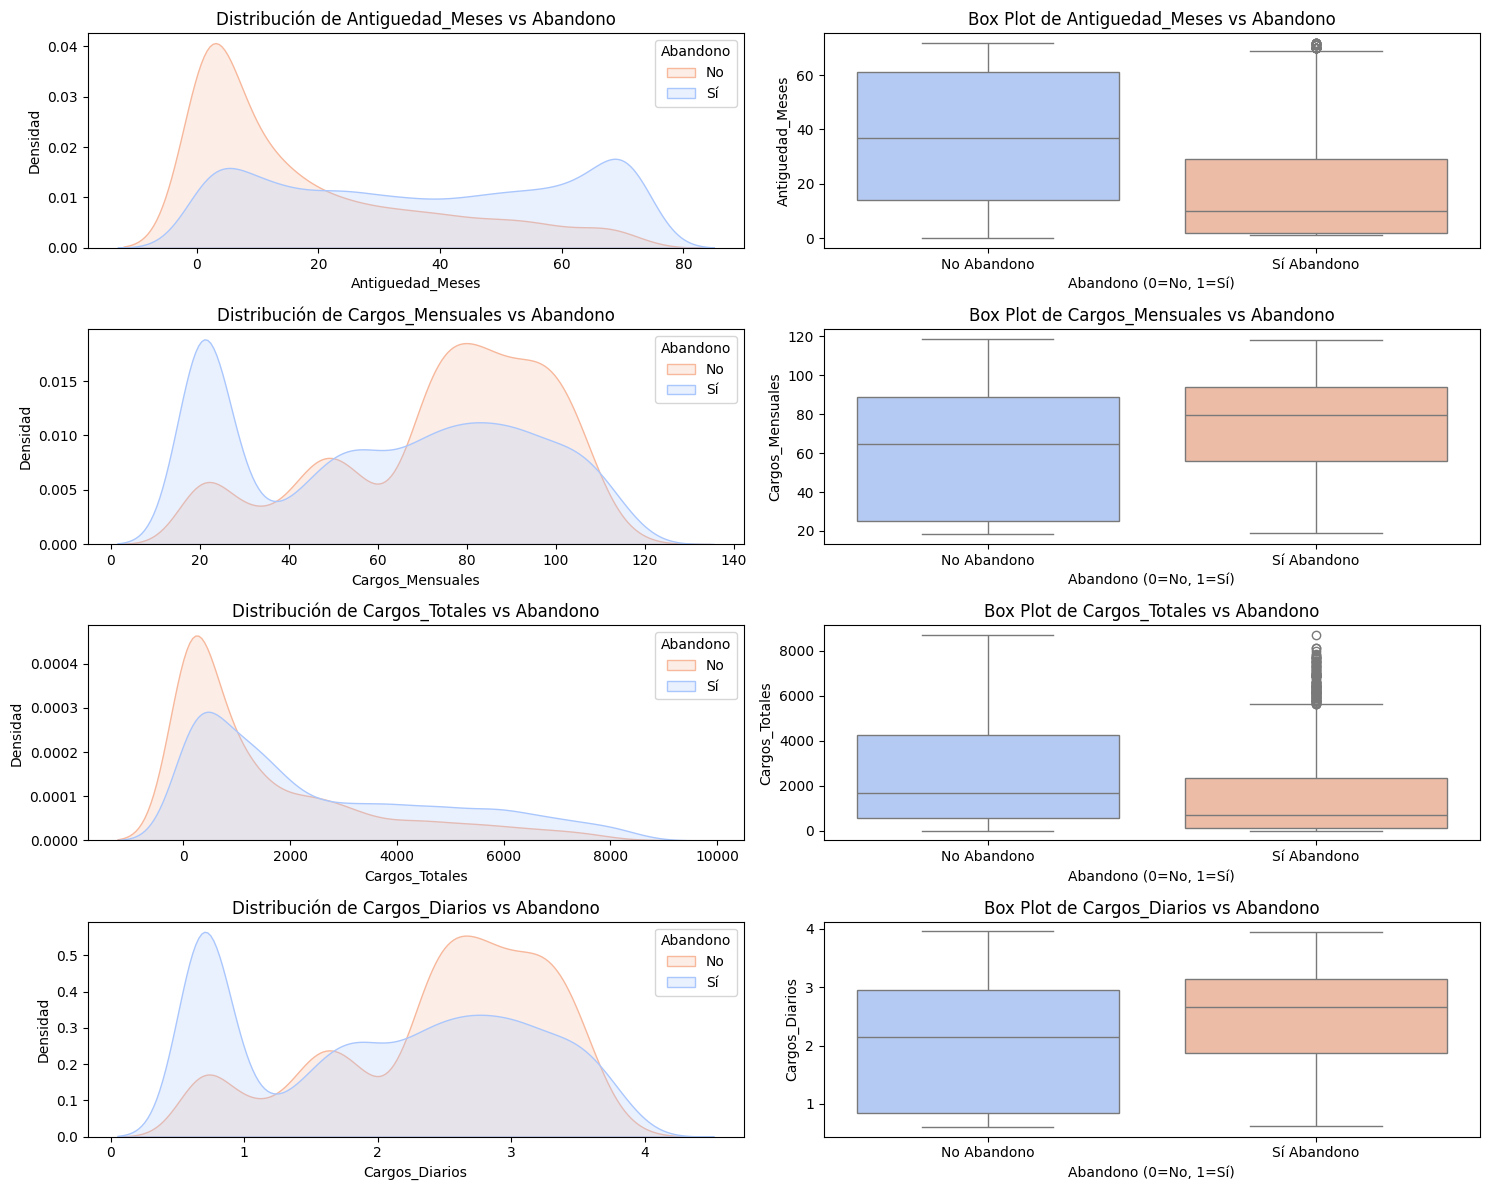

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = [
    'Antiguedad_Meses',
    'Cargos_Mensuales',
    'Cargos_Totales',
    'Cargos_Diarios'
]

plt.figure(figsize=(15, 12))

for i, col in enumerate(numerical_cols):
    # KDE Plot
    plt.subplot(len(numerical_cols), 2, 2*i + 1)
    sns.kdeplot(data=df, x=col, hue='Abandono', fill=True, palette='coolwarm', common_norm=False)
    plt.title(f'Distribución de {col} vs Abandono')
    plt.xlabel(col)
    plt.ylabel('Densidad')
    plt.legend(title='Abandono', labels=['No', 'Sí'])

    # Box Plot
    plt.subplot(len(numerical_cols), 2, 2*i + 2)
    sns.boxplot(data=df, x='Abandono', y=col, palette='coolwarm')
    plt.title(f'Box Plot de {col} vs Abandono')
    plt.xlabel('Abandono (0=No, 1=Sí)')
    plt.ylabel(col)
    plt.xticks(ticks=[0, 1], labels=['No Abandono', 'Sí Abandono'])

plt.tight_layout()
plt.show()


#📄Informe final

📄 Informe Final del Análisis de Abandono de Clientes (Churn) en TelecomX

## 🔹 Introducción

El presente informe tiene como objetivo analizar el fenómeno de la evasión de clientes, conocido como *churn*, en la empresa de telecomunicaciones TelecomX. La evasión de clientes representa una pérdida significativa de ingresos y una amenaza para la estabilidad del negocio. Comprender los factores que impulsan a los clientes a abandonar los servicios es crucial para desarrollar estrategias de retención efectivas y mantener la base de clientes.

Este análisis busca identificar patrones y correlaciones en los datos de los clientes de TelecomX que puedan explicar el comportamiento de abandono. Al desentrañar las causas subyacentes, podremos proponer recomendaciones estratégicas para mitigar el churn y mejorar la lealtad del cliente.

## 🔹 Limpieza y Tratamiento de Datos

El proceso de preparación de los datos fue fundamental para asegurar la calidad y la estructura adecuada para el análisis:

1.  **Extracción de Datos**: Los datos fueron cargados desde un archivo JSON (`TelecomX_Data.json`) almacenado en Google Drive, utilizando la librería `pandas`.

2.  **Aplanamiento de Columnas Anidadas**: El conjunto de datos inicial contenía información anidada en formato JSON dentro de columnas como `'phone'`, `'internet'`, `'account'` y `'customer'`. Estas columnas fueron aplanadas (`pd.json_normalize`) para transformar sus datos en nuevas columnas individuales dentro del DataFrame principal. Esto permitió un acceso más fácil a la información contenida en ellas.

3.  **Corrección de Formato y Valores Ausentes**:
    *   La columna `'Charges.Total'` (`Cargos_Totales`) se identificó como tipo `object` (cadena de texto) y contenía valores vacíos que causaban errores. Se convirtió a tipo numérico (`float64`) y los valores vacíos fueron reemplazados por la mediana de la columna para mantener la integridad de los datos.
    *   La columna `'Churn'` (`Abandono`) contenía valores vacíos (`''`) que se reemplazaron por `'No'`, asumiendo que los registros incompletos no indicaban abandono activo.

4.  **Estandarización de Texto**: Para asegurar consistencia, se aplicó la función `.lower()` a columnas categóricas como `'gender'` (`Genero`) y `'Contract'` (`Contrato`), transformando todos los valores a minúsculas.

5.  **Creación de Nuevas Características**: Se creó una nueva columna llamada `'Cuentas_Diarias'` (`Cargos_Diarios`) calculando los cargos mensuales divididos por 30. Esta métrica ofrece una perspectiva diaria del costo para el cliente.

6.  **Binarización de Variables Categóricas**: Numerosas columnas categóricas que representaban opciones binarias (Sí/No) o categorías de servicio (e.g., 'No phone service', 'No internet service') fueron binarizadas a valores numéricos (1 para 'Sí' o servicio presente, 0 para 'No' o servicio ausente). Esto incluyó columnas como `'Churn'`, `'Partner'`, `'Dependents'`, `'PhoneService'`, `'PaperlessBilling'`, y todas las relacionadas con servicios de internet y telefonía.

7.  **Renombrado de Columnas**: Todas las columnas fueron renombradas a español para mejorar la legibilidad y comprensión del DataFrame.

## 🔹 Análisis Exploratorio de Datos (EDA)

Se realizaron varios análisis para entender la distribución de las variables y su relación con el abandono:

### Distribución General del Abandono

*   **Observación**: La distribución de la variable `'Abandono'` mostró un desequilibrio significativo, con aproximadamente el 25.7% de los clientes habiendo abandonado el servicio. Esto indica que la mayoría de los clientes son retenidos, pero el porcentaje de abandono es lo suficientemente alto como para requerir atención.

### Análisis de Variables Categóricas vs. Abandono

Se exploró la relación entre las variables categóricas y el abandono utilizando gráficos de conteo. Los hallazgos clave incluyen:

*   **Contrato (`Contrato`)**: Los clientes con contratos **'month-to-month' (mes a mes)** presentan una tasa de abandono considerablemente más alta en comparación con aquellos con contratos de 'one year' (un año) o 'two year' (dos años). La flexibilidad de los contratos a corto plazo parece ser un factor de riesgo.

*   **Método de Pago (`Metodo_Pago`)**: El **'Electronic check' (cheque electrónico)** se asocia con la mayor tasa de abandono. Esto podría ser un indicio de insatisfacción con este método o con los clientes que lo prefieren.

*   **Servicio de Internet (`Servicio_Internet`)**: Los clientes con **'Fiber optic' (fibra óptica)** muestran una tasa de abandono superior. Esto sugiere que las altas expectativas o una fuerte competencia en el segmento de fibra óptica podrían influir.

*   **Relaciones Familiares (`Pareja`, `Dependientes`)**: Los clientes sin pareja y sin dependientes (`Pareja=0`, `Dependientes=0`) tienen una mayor propensión a la evasión, lo que sugiere que las responsabilidades familiares pueden aumentar la lealtad.

*   **Ciudadano Senior (`Ciudadano_Senior`)**: Los clientes de mayor edad (SeniorCitizen=1) tienen una tasa de abandono ligeramente superior.

*   **Servicios Adicionales**: La ausencia de servicios adicionales como seguridad online, copia de seguridad, protección de dispositivos, soporte técnico, y streaming de TV/películas, se correlaciona con tasas de abandono más altas. Estos servicios parecen ser importantes para la retención.

*   **Facturación Sin Papel (`Facturacion_Sin_Papel`)**: Los clientes que optan por la facturación sin papel (`Facturacion_Sin_Papel=1`) muestran una mayor tendencia al abandono.

*   **Género (`Genero`)**: No se encontró una diferencia significativa en la tasa de abandono entre géneros.

### Análisis de Variables Numéricas vs. Abandono

Se examinó la distribución de variables numéricas utilizando gráficos KDE y box plots:

*   **Antigüedad en Meses (`Antiguedad_Meses`)**: Existe una fuerte correlación inversa con el abandono. Los clientes que **abandonan** tienen una antigüedad significativamente más baja (con un pico en los primeros meses de servicio). Los clientes con mayor antigüedad son mucho más leales.

*   **Cargos Mensuales (`Cargos_Mensuales`) y Cargos Diarios (`Cargos_Diarios`)**: Los clientes con **cargos mensuales y diarios más altos** tienden a tener una mayor tasa de abandono. Esto sugiere que el costo elevado puede ser un factor de descontento.

*   **Cargos Totales (`Cargos_Totales`)**: Los clientes que **abandonan** presentan cargos totales acumulados mucho más bajos. Esto es coherente con su menor antigüedad; sin embargo, un bajo cargo total combinado con un alto cargo mensual es una señal de alerta.

## 🔹 Conclusiones e Insights

El análisis de datos ha revelado un perfil claro del cliente propenso al abandono en TelecomX:

*   **Cliente de Alto Riesgo**: Es probable que sea un cliente relativamente **nuevo** (baja antigüedad), con un **contrato mes a mes**, utilizando **fibra óptica** como servicio de internet, pagando con **cheque electrónico**, con **cargos mensuales elevados**, y a menudo **sin pareja ni dependientes**. Además, es común que no haya contratado **servicios adicionales** de seguridad o entretenimiento.

*   **Período Crítico**: Los **primeros meses** de servicio son el período más vulnerable para el abandono. La experiencia inicial del cliente es determinante.

*   **Valor Percibido vs. Costo**: Clientes con **altos cargos mensuales** son más susceptibles al abandono, lo que sugiere una posible brecha entre el costo del servicio y el valor percibido por el cliente.

*   **Factores de Lealtad**: Los contratos a largo plazo y la tenencia de servicios adicionales (seguridad, soporte) son fuertes indicadores de lealtad.

Estos insights demuestran que el abandono no es aleatorio, sino que está impulsado por una combinación de factores demográficos, de servicio y contractuales que, una vez identificados, pueden ser abordados estratégicamente.

## 🔹 Recomendaciones

Basado en los hallazgos de este análisis, se proponen las siguientes recomendaciones estratégicas para TelecomX con el fin de reducir la evasión de clientes:

1.  **Programas de Retención Temprana**:
    *   **Enfoque**: Implementar programas de bienvenida y seguimiento intensivo durante los primeros 6-12 meses de servicio, especialmente para clientes con contratos mes a mes y fibra óptica.
    *   **Acciones**: Ofrecer incentivos para extender contratos a largo plazo, asegurar una excelente experiencia de onboarding y soporte proactivo para resolver cualquier problema inicial.

2.  **Revisión de Estructura de Precios y Valor**:
    *   **Enfoque**: Evaluar la competitividad y el valor percibido de los servicios, especialmente para clientes con cargos mensuales elevados.
    *   **Acciones**: Considerar ofrecer paquetes más atractivos, descuentos por lealtad para clientes de alto consumo, o comunicar de manera más efectiva el valor y los beneficios de los servicios actuales.

3.  **Optimización de Métodos de Pago**:
    *   **Enfoque**: Investigar la insatisfacción asociada con el 'cheque electrónico' como método de pago.
    *   **Acciones**: Mejorar la interfaz de usuario, ofrecer tutoriales claros, o incentivar el uso de métodos de pago más estables y convenientes (como domiciliación bancaria o tarjeta de crédito automática) con beneficios adicionales.

4.  **Promoción de Servicios Adicionales**:
    *   **Enfoque**: Destacar el valor y los beneficios de los servicios de valor agregado (seguridad online, copia de seguridad, soporte técnico, streaming).
    *   **Acciones**: Ofrecer pruebas gratuitas, paquetes combinados atractivos, o campañas de marketing dirigidas para educar a los clientes sobre cómo estos servicios mejoran su experiencia y reducen la probabilidad de abandono.

5.  **Segmentación y Personalización**:
    *   **Enfoque**: Utilizar el perfil de riesgo identificado para segmentar a los clientes y personalizar las ofertas de retención.
    *   **Acciones**: Diseñar campañas específicas para clientes sin pareja/dependientes, ofrecer planes familiares o beneficios adaptados a sus necesidades para fomentar la lealtad a largo plazo.

Al implementar estas recomendaciones, TelecomX puede transformar los conocimientos adquiridos en acciones concretas que no solo reducirán la tasa de abandono, sino que también fortalecerán la relación con sus clientes.